In [2]:
%run ../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from src.data.diagnose import apply_diagnostic
from src.utils.visualization import plot_lbp_multi_metric
import os
from pathlib import Path
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.data.patch_extraction import build_patch_dataset
from src.evaluate import print_summary
from src.data.dataset import KidneyStoneDataset
from src.pipelines.resnet50_pipeline import resnet50
import pandas as pd
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
from src.features.feature_extractor import FeatureExtractor 
from src.pipelines.xgboost_pipeline import XGBoostExperiment
from src.utils.io import load_image, load_mask


In [2]:

diag_df = apply_diagnostic(root_path= DATASET_PATH_XGBOOST,classes= ["1aI","2a", "3aII","3bII","4II-4I", "6", "8aI - 8aII"])
print(diag_df.describe())

       stone_pixels    coverage  n_fragments  min_fragment_pixels  \
count  3.970000e+02  397.000000   397.000000         3.970000e+02   
mean   9.119726e+05    0.370928     4.287154         3.810989e+05   
std    3.353543e+05    0.136399     6.826727         4.452478e+05   
min    1.730660e+05    0.070391     1.000000         1.000000e+00   
25%    6.604010e+05    0.268606     1.000000         4.000000e+00   
50%    9.175420e+05    0.373193     2.000000         1.283230e+05   
75%    1.105020e+06    0.449447     5.000000         7.571310e+05   
max    2.079346e+06    0.845736    69.000000         1.447639e+06   

       max_fragment_pixels  
count         3.970000e+02  
mean          8.040571e+05  
std           3.554795e+05  
min           1.063050e+05  
25%           5.248980e+05  
50%           8.182170e+05  
75%           1.057452e+06  
max           1.991049e+06  


In [3]:
def plot_violin_by_class(df, class_col="folder", figsize=(14, 10)):
    variables = [
        ("stone_pixels", "Píxeles de cálculo"),
        ("coverage", "Coverage"),
        ("n_fragments", "Número de fragmentos"),
        ("max_fragment_pixels", "Tamaño fragmento principal"),
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    for ax, (col, title) in zip(axes, variables):
        classes = sorted(df[class_col].unique())
        data_by_class = [df[df[class_col] == c][col].dropna().values for c in classes]
        
        parts = ax.violinplot(data_by_class, showmeans=False, showmedians=True,
                               showextrema=True)
        
        for body in parts["bodies"]:
            body.set_facecolor("steelblue")
            body.set_alpha(0.7)
            body.set_edgecolor("black")
        
        # Personalizar las líneas 
        for line_name in ("cmedians", "cmins", "cmaxes", "cbars"):
            if line_name in parts:
                parts[line_name].set_color("darkblue")
                parts[line_name].set_linewidth(1.5)
        
        ax.set_xticks(range(1, len(classes) + 1))
        ax.set_xticklabels(classes, rotation=45)
        ax.set_title(title)
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.3)
        
        if col in ("stone_pixels", "max_fragment_pixels"):
            ax.set_yscale("log")
    
    plt.suptitle(f"Distribución de variables por {class_col}",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    return fig

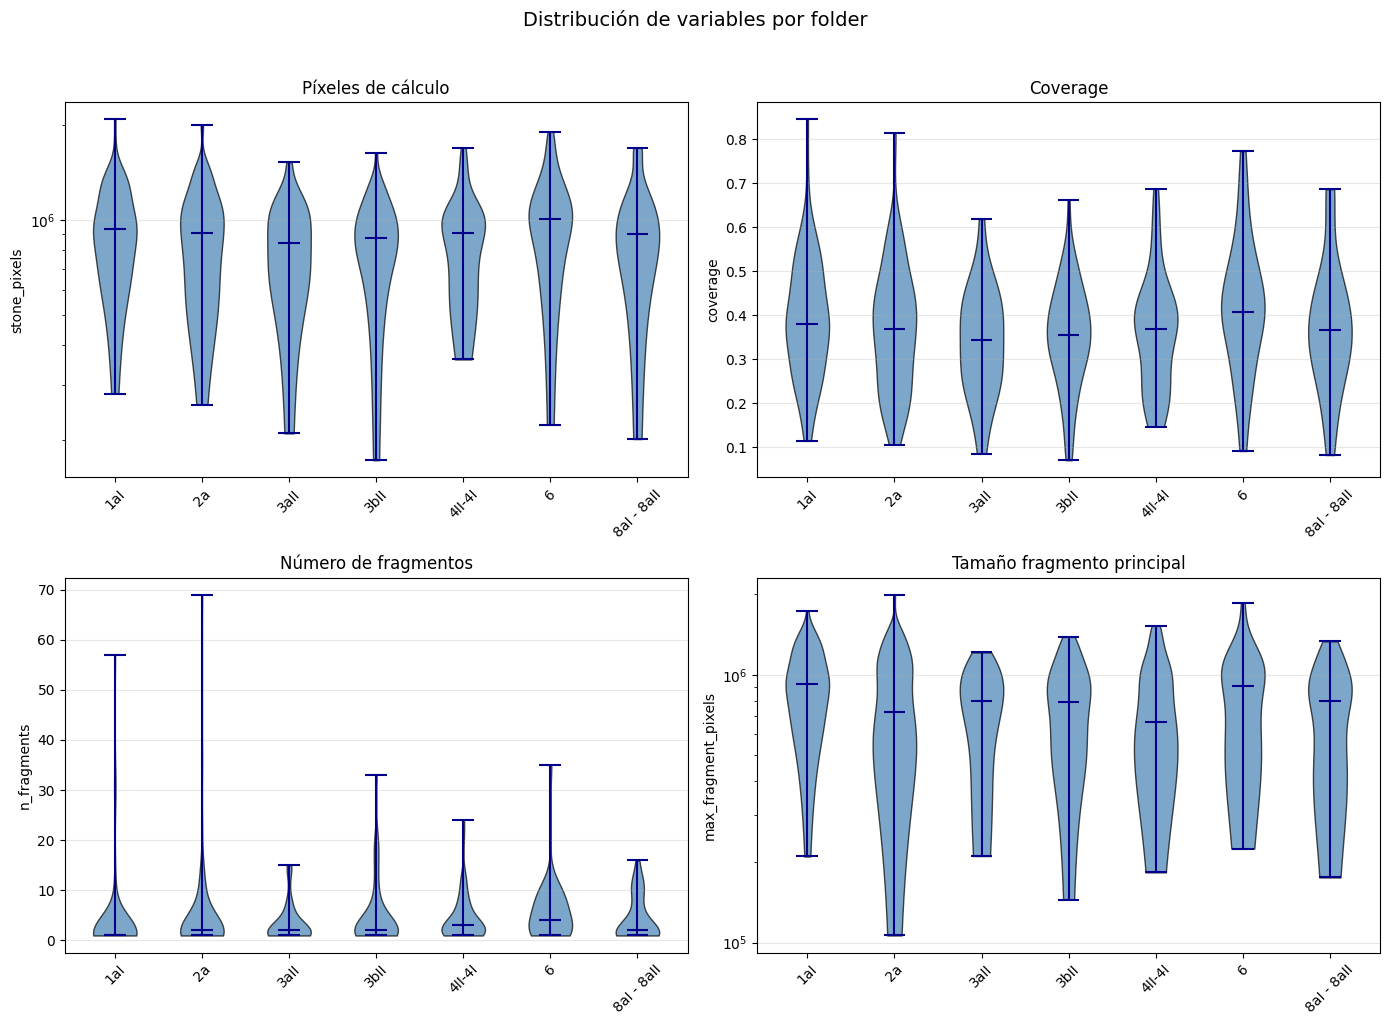

In [4]:
plot1= plot_violin_by_class(diag_df)
plot1.show()
plot1.savefig("experiments/plots/ditribución de variables por classe",dpi=100)

In [6]:

# 1. Construir el DataFrame original
builder = DatasetBuilder(root_path= DATASET_PATH_XGBOOST)
df = builder.build(classes= [["1aI"], ["2a"],["3aII"],["3bII"], ["4II-4I"],["6"],["8aI - 8aII"] ])  
for patch_size in PATCH_CONFIG:
    # 2. Extraer patches y guardarlos en disco
    patches_df = build_patch_dataset(
        df=df,
        output_dir=Path(PATCHES_DIR/f"{patch_size}"),
        patch_size=patch_size,
        num_patches=30,
        min_coverage=MIN_COVERAGE,
        min_distance_between_centers=PATCH_CONFIG.get(patch_size),
        max_attempts= 600,
    )
    
    # 3. Guardar el DataFrame de patches para reutilizar
    patches_df.to_csv(f"experiments/patches_{patch_size}_metadata.csv", index=False)


Extracting patches: 100%|██████████| 397/397 [02:35<00:00,  2.55it/s]



[Patch extraction summary]
  Source images:   397
  Patches created: 9881
  Skipped images:  0 too small


Extracting patches: 100%|██████████| 397/397 [02:55<00:00,  2.26it/s]



[Patch extraction summary]
  Source images:   397
  Patches created: 8403
  Skipped images:  0 too small


Extracting patches: 100%|██████████| 397/397 [02:57<00:00,  2.24it/s]



[Patch extraction summary]
  Source images:   397
  Patches created: 6704
  Skipped images:  0 too small


Extracting patches: 100%|██████████| 397/397 [02:54<00:00,  2.28it/s]


[Patch extraction summary]
  Source images:   397
  Patches created: 5290
  Skipped images:  1 too small
  Skipped IDs:     ['4II_6']


  Features shape: (9881, 40)
  Distribución: {0: 4884, 1: 4997}

BÚSQUEDA HP: patch_size_224
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.8607
  Best params: {'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 492, 'learning_rate': 0.01747890096415039, 'subsample': 0.6210413319451669, 'colsample_bytree': 0.44417584274000343}

EVALUACIÓN CV: patch_size_224 (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.8544 | precision_weighted=0.8558 | recall_weighted=0.8544 | f1_weighted=0.8530 | specificity_weighted=0.8343 | npv_weighted=0.8600 | auc_weighted=0.9269
  Fold 2: accuracy=0.7787 | precision_weighted=0.7809 | recall_weighted=0.7787 | f1_weighted=0.7794 | specificity_weighted=0.7765 | npv_weighted=0.7677 | auc_weighted=0.8450
  Fold 3: accuracy=0.7893 | precision_weighted=0.7985 | recall_weighted=0.7893 | f1_weighted=0.7889 | specificity_weighted=0.7966 | npv_weighted=0.7923 | auc_weighted=0.8730
  Fold 4: accuracy=0.7886 | precision_weighted=0.7883 | recall_weighted=0.7886 | f1_weighted=0.7884 | specificity_weighted=0.7826 | npv_weighted=0.7850 | auc_weighted=0.8726
  Fold 5: accuracy=0.7107 | p

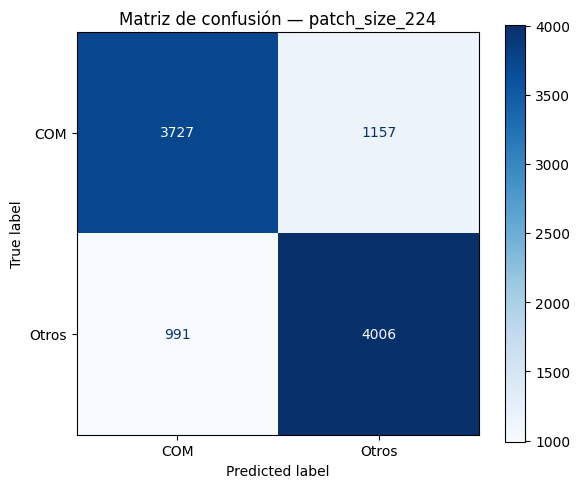


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8360 ± 0.0729
  auc_weighted: 0.9251 ± 0.0390
  f1_weighted: 0.8350 ± 0.0735
  npv_weighted: 0.8415 ± 0.0743
  precision_weighted: 0.8425 ± 0.0703
  recall_weighted: 0.8360 ± 0.0729
  specificity_weighted: 0.8322 ± 0.0664


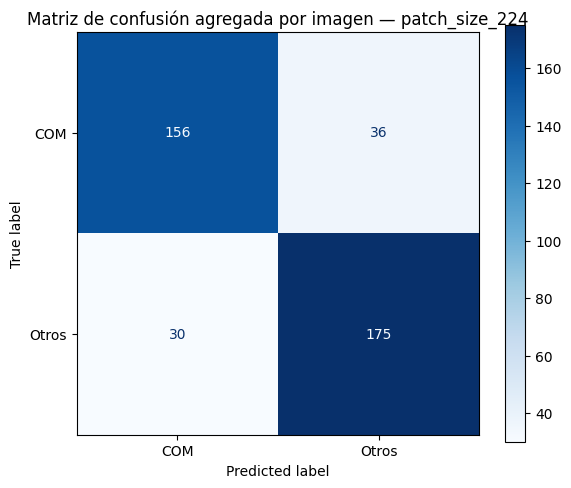

  Features shape: (8403, 40)
  Distribución: {0: 4229, 1: 4174}

BÚSQUEDA HP: patch_size_256
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.8593
  Best params: {'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 262, 'learning_rate': 0.09164090558998977, 'subsample': 0.6764950597883993, 'colsample_bytree': 0.4182181595998745}

EVALUACIÓN CV: patch_size_256 (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.8360 | precision_weighted=0.8387 | recall_weighted=0.8360 | f1_weighted=0.8362 | specificity_weighted=0.8396 | npv_weighted=0.8336 | auc_weighted=0.9058
  Fold 2: accuracy=0.7724 | precision_weighted=0.7724 | recall_weighted=0.7724 | f1_weighted=0.7724 | specificity_weighted=0.7631 | npv_weighted=0.7634 | auc_weighted=0.8551
  Fold 3: accuracy=0.7562 | precision_weighted=0.7588 | recall_weighted=0.7562 | f1_weighted=0.7559 | specificity_weighted=0.7579 | npv_weighted=0.7576 | auc_weighted=0.8386
  Fold 4: accuracy=0.7655 | precision_weighted=0.7714 | recall_weighted=0.7655 | f1_weighted=0.7662 | specificity_weighted=0.7718 | npv_weighted=0.7593 | auc_weighted=0.8182
  Fold 5: accuracy=0.7684 | pr

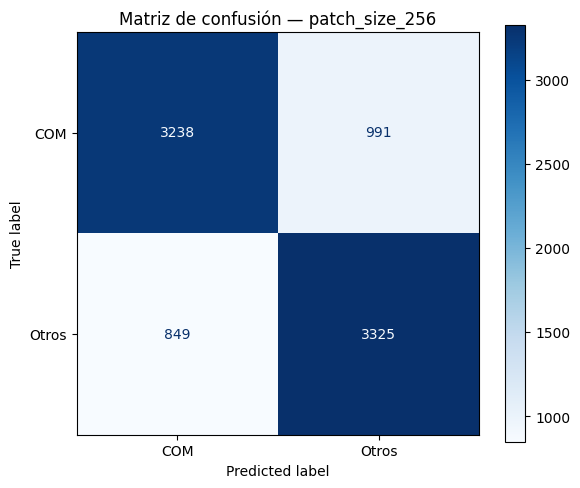


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8179 ± 0.0435
  auc_weighted: 0.9197 ± 0.0365
  f1_weighted: 0.8179 ± 0.0436
  npv_weighted: 0.8170 ± 0.0425
  precision_weighted: 0.8236 ± 0.0452
  recall_weighted: 0.8179 ± 0.0435
  specificity_weighted: 0.8230 ± 0.0465


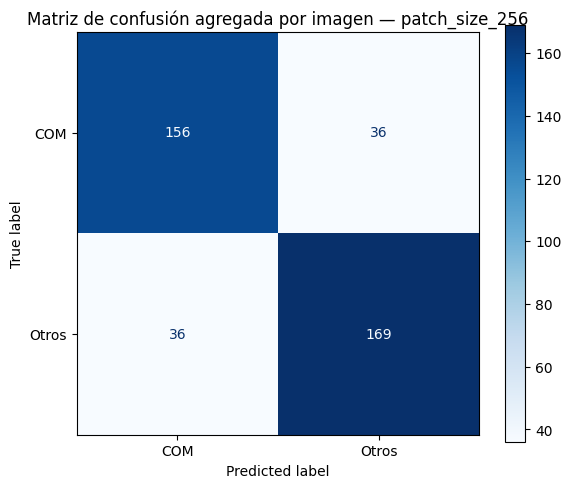

  Features shape: (6704, 40)
  Distribución: {0: 3440, 1: 3264}

BÚSQUEDA HP: patch_size_288
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.8607
  Best params: {'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 592, 'learning_rate': 0.03573430107539696, 'subsample': 0.5557870268487767, 'colsample_bytree': 0.41032175424979006}

EVALUACIÓN CV: patch_size_288 (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.7547 | precision_weighted=0.7540 | recall_weighted=0.7547 | f1_weighted=0.7542 | specificity_weighted=0.7411 | npv_weighted=0.7457 | auc_weighted=0.8270
  Fold 2: accuracy=0.7658 | precision_weighted=0.7723 | recall_weighted=0.7658 | f1_weighted=0.7655 | specificity_weighted=0.7712 | npv_weighted=0.7679 | auc_weighted=0.8509
  Fold 3: accuracy=0.7676 | precision_weighted=0.7676 | recall_weighted=0.7676 | f1_weighted=0.7676 | specificity_weighted=0.7669 | npv_weighted=0.7675 | auc_weighted=0.8223
  Fold 4: accuracy=0.8165 | precision_weighted=0.8195 | recall_weighted=0.8165 | f1_weighted=0.8167 | specificity_weighted=0.8201 | npv_weighted=0.8150 | auc_weighted=0.9021
  Fold 5: accuracy=0.8259 | p

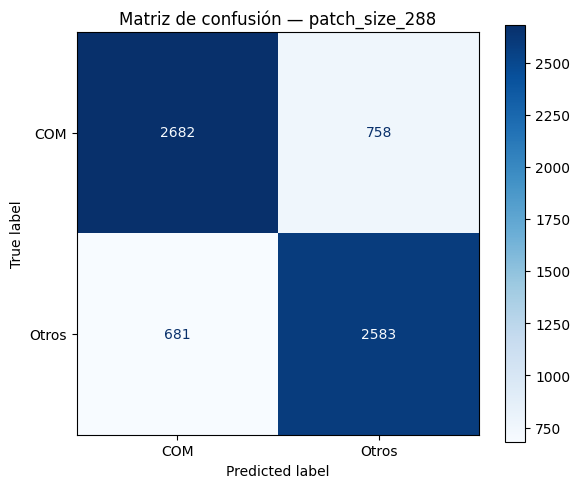


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8141 ± 0.0289
  auc_weighted: 0.9140 ± 0.0226
  f1_weighted: 0.8140 ± 0.0294
  npv_weighted: 0.8124 ± 0.0266
  precision_weighted: 0.8178 ± 0.0315
  recall_weighted: 0.8141 ± 0.0289
  specificity_weighted: 0.8157 ± 0.0356


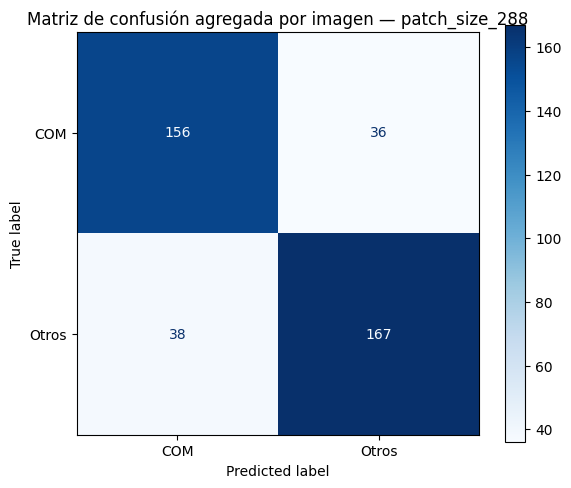

  Features shape: (5290, 40)
  Distribución: {0: 2767, 1: 2523}

BÚSQUEDA HP: patch_size_320
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.8728
  Best params: {'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 374, 'learning_rate': 0.018056515287863818, 'subsample': 0.7898779593974955, 'colsample_bytree': 0.47894491301661757}

EVALUACIÓN CV: patch_size_320 (5 folds)
  use_augmentation = False
  Fold 1: accuracy=0.8103 | precision_weighted=0.8113 | recall_weighted=0.8103 | f1_weighted=0.8104 | specificity_weighted=0.8115 | npv_weighted=0.8095 | auc_weighted=0.8754
  Fold 2: accuracy=0.7748 | precision_weighted=0.7763 | recall_weighted=0.7748 | f1_weighted=0.7752 | specificity_weighted=0.7741 | npv_weighted=0.7686 | auc_weighted=0.8594
  Fold 3: accuracy=0.7975 | precision_weighted=0.8013 | recall_weighted=0.7975 | f1_weighted=0.7979 | specificity_weighted=0.8020 | npv_weighted=0.7931 | auc_weighted=0.8685
  Fold 4: accuracy=0.7865 | precision_weighted=0.8048 | recall_weighted=0.7865 | f1_weighted=0.7894 | specificity_weighted=0.8059 | npv_weighted=0.7555 | auc_weighted=0.8779
  Fold 5: accuracy=0.7920 | 

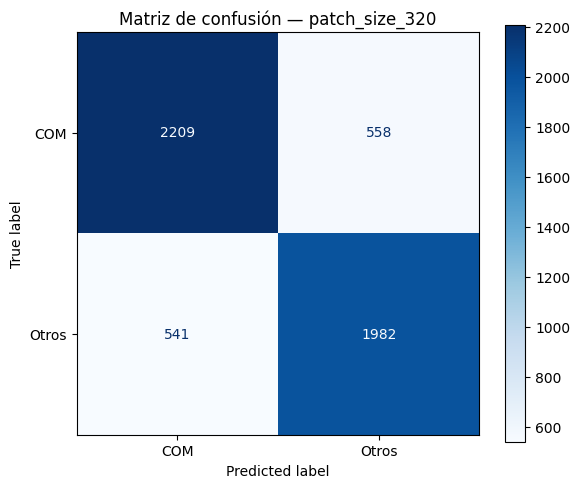


 Métricas agregadas a nivel imagen (media ± std entre folds):

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8346 ± 0.0319
  auc_weighted: 0.9190 ± 0.0230
  f1_weighted: 0.8353 ± 0.0315
  npv_weighted: 0.8261 ± 0.0356
  precision_weighted: 0.8426 ± 0.0267
  recall_weighted: 0.8346 ± 0.0319
  specificity_weighted: 0.8445 ± 0.0256


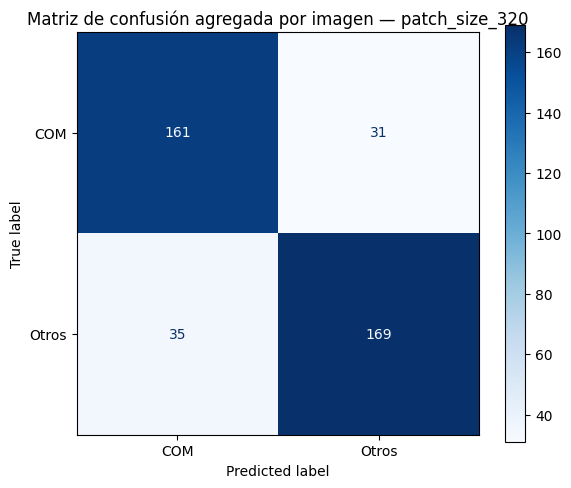

In [7]:

task= TASKS["binario"]
evaluations= []
for patch_size in PATCH_CONFIG:
        lbp = LocalBinaryPattern()
        hsv = HSV_extractor()
        extractor = FeatureExtractor(hsv, lbp)
        file_name= f"experiments/patches_{patch_size}_metadata.csv"
        patch_df=pd.read_csv(file_name) 
        patches_task = assign_task_labels(patch_df, task)
        exp_name = f"patch_size_{patch_size}"
        config = {
            "name": exp_name,
            "output_dir": str(f"experiments/patch_size/{patch_size}"),
            "class_names": task["class_names"],
        }
        model = XGBoostExperiment(patches_task, extractor, Case.PATCH)
        #buscar los mejores hiperparametros por cada patch_size
        result= model.search_hyperparameters(config)
        #evaluar el modelo
        evaluation= model.evaluate_cv(config, result["best_params"], show_fold_metrics= True)
        evaluations.append(evaluation)
    

In [13]:
def evaluations_to_results(evaluations):
    results= []
    for e in evaluations:
        print(e["name"])
        s = e["summary"]
        results.append({
            "patch_size": e["name"].split('_')[2],
            "f1_weighted_mean": s["f1_weighted_mean"],
            "f1_weighted_std": s["f1_weighted_std"],
            "accuracy_mean": s["accuracy_mean"],
            "accuracy_std": s["accuracy_std"],
            "auc_weighted_mean": s.get("auc_weighted_mean"),
            "auc_weighted_std": s.get("auc_weighted_std"),
        })
    return results

In [8]:

results_df= pd.DataFrame(evaluations_to_results(evaluations))
    
    # print_summary(e["summary"])

patch_size_224
patch_size_256
patch_size_288
patch_size_320


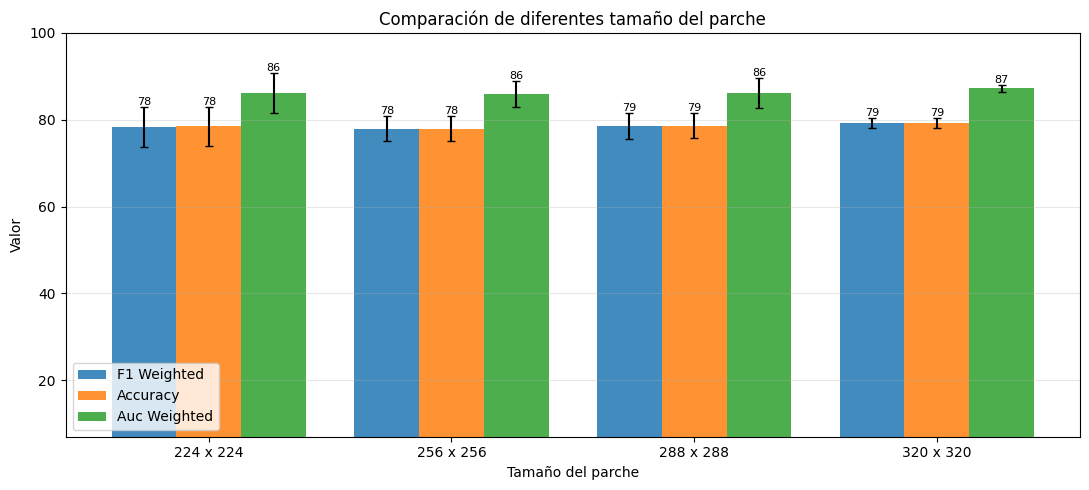

In [21]:

fig_image = plot_lbp_multi_metric(df= results_df, labels = ["224 x 224", "256 x 256", "288 x 288", "320 x 320"], xlabel="Tamaño del parche", ylabel= "Valor", title= "Comparación de diferentes tamaño del parche" )
fig_image.show()
fig_image.savefig("experiments/plots/comparación tamaños de parches", dpi= 100)

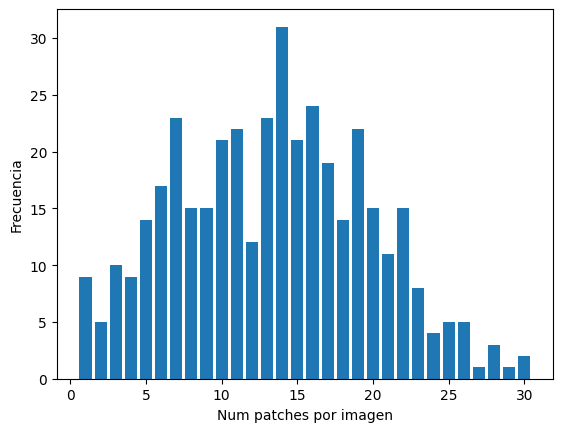

In [12]:

patches_df= pd.read_csv("experiments/patches_320_metadata.csv")
patches_per_image= patches_df.groupby("source_image").size().reset_index(name= "num_patches_per_image")
frequency= patches_per_image.groupby("num_patches_per_image").size().reset_index(name="frequency")
plt.bar(frequency["num_patches_per_image"], frequency["frequency"])
plt.xlabel("Num patches por imagen")
plt.ylabel("Frecuencia")
plt.show()

Use weighted cross entropy: False

EXPERIMENTO K-FOLD: resent50_patch_size_224
Total patchs: 9881
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 6954 patchs (215 cálculos)
  Val:   1258 patchs (34 cálculos)
  Test:  1669 patchs (63 cálculos)
Device: cuda
Trainable parameters: 525,570
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.4964 acc=0.7631 f1=0.7630 | val: loss=0.4580 acc=0.7846 f1=0.7900 | lr=1.00e-04 | 16.6s
Epoch   2/30 | train: loss=0.4472 acc=0.7915 f1=0.7914 | val: loss=0.4330 acc=0.8037 f1=0.8082 | lr=1.00e-04 | 16.5s
Epoch   3/30 | train: loss=0.4327 acc=0.8020 f1=0.8019 | val: loss=0.4681 acc=0.7774 f1=0.7833 | lr=1.00e-04 | 16.5s
Epoch   4/30 | train: loss=0.4160 acc=0.8086 f1=0.8086 | val: loss=0.4449 acc=0.7846 f1=0.7898 | lr=1.00e-04 | 16.6s
Epoch   5/30 | train: loss=0.4109 acc=0.8152 f1=0.8152 | val: loss=0.4376 acc=0.8037 f1=0.8077 | lr=1.00e-04 | 16.6s
Epoch   6/30 | train: loss=0.4035 acc=0.8232 f1=0.8231 | v

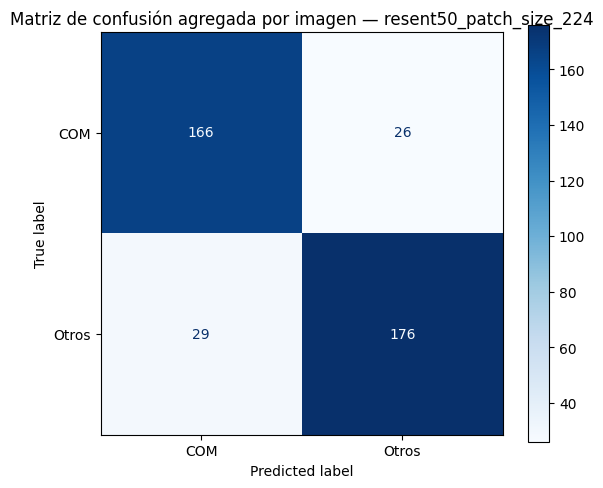

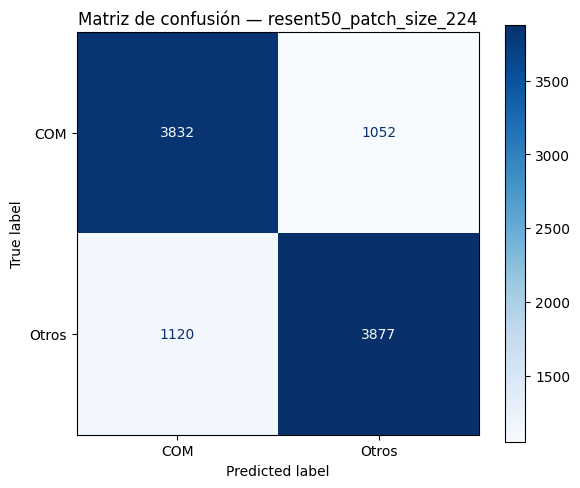


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7802 ± 0.0328
  auc_weighted: 0.8727 ± 0.0320
  f1_weighted: 0.7800 ± 0.0337
  precision_weighted: 0.7867 ± 0.0297
  recall_weighted: 0.7802 ± 0.0328
Use weighted cross entropy: False

EXPERIMENTO K-FOLD: resent50_patch_size_256
Total patchs: 8403
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 5647 patchs (217 cálculos)
  Val:   896 patchs (34 cálculos)
  Test:  1860 patchs (61 cálculos)
Device: cuda
Trainable parameters: 525,570
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.4989 acc=0.7591 f1=0.7589 | val: loss=0.4706 acc=0.7578 f1=0.7551 | lr=1.00e-04 | 14.5s
Epoch   2/30 | train: loss=0.4416 acc=0.7915 f1=0.7916 | val: loss=0.4153 acc=0.7991 f1=0.7978 | lr=1.00e-04 | 13.4s
Epoch   3/30 | train: loss=0.4254 acc=0.8088 f1=0.8087 | val: loss=0.4134 acc=0.8013 f1=0.8014 | lr=1.00e-04 | 13.4s
Epoch   4/30 | train: loss=0.4186 acc=0.8059 f1=0.8059 | val: loss=0.4205 acc=0

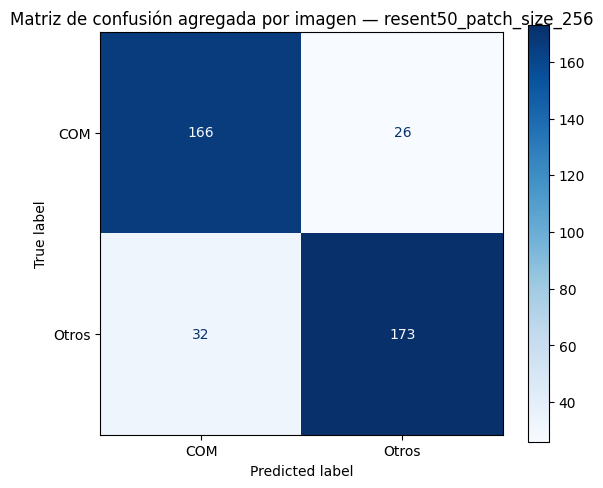

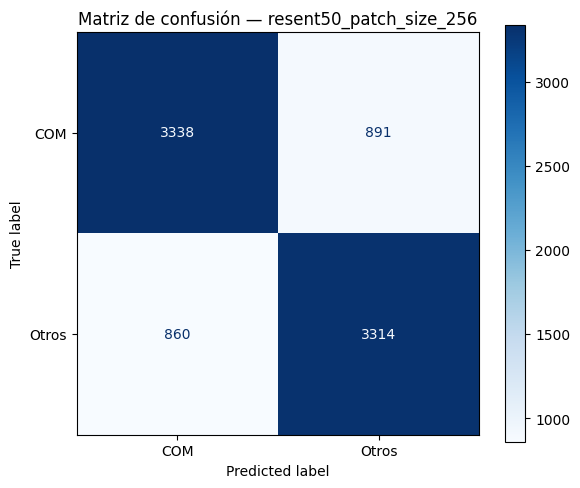


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7898 ± 0.0277
  auc_weighted: 0.8754 ± 0.0305
  f1_weighted: 0.7894 ± 0.0280
  precision_weighted: 0.7953 ± 0.0281
  recall_weighted: 0.7898 ± 0.0277
Use weighted cross entropy: False

EXPERIMENTO K-FOLD: resent50_patch_size_288
Total patchs: 6704
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 4580 patchs (216 cálculos)
  Val:   742 patchs (34 cálculos)
  Test:  1382 patchs (62 cálculos)
Device: cuda
Trainable parameters: 525,570
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.4471 acc=0.7924 f1=0.7922 | val: loss=0.6206 acc=0.7237 f1=0.7198 | lr=1.00e-04 | 13.8s
Epoch   2/30 | train: loss=0.3739 acc=0.8344 f1=0.8344 | val: loss=0.6384 acc=0.7143 f1=0.7080 | lr=1.00e-04 | 11.0s
Epoch   3/30 | train: loss=0.3620 acc=0.8435 f1=0.8435 | val: loss=0.6452 acc=0.7210 f1=0.7163 | lr=1.00e-04 | 11.0s
Epoch   4/30 | train: loss=0.3647 acc=0.8389 f1=0.8389 | val: loss=0.6094 acc=0

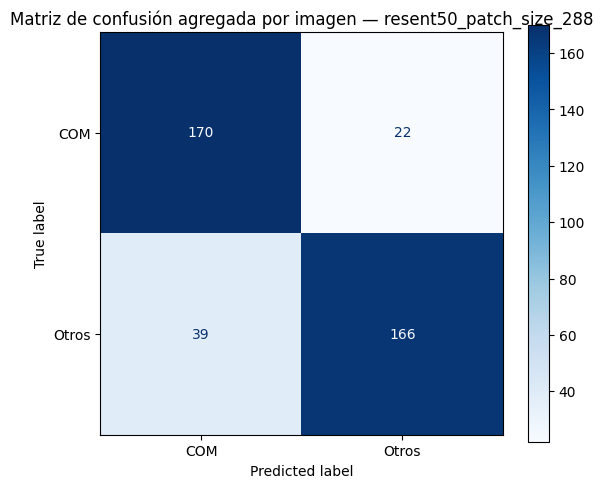

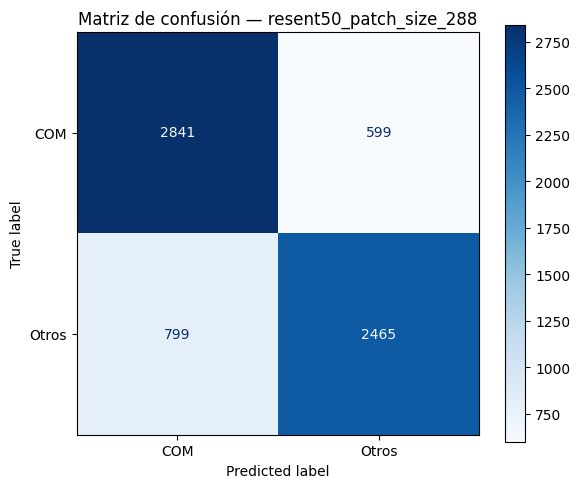


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.7913 ± 0.0288
  auc_weighted: 0.8770 ± 0.0232
  f1_weighted: 0.7906 ± 0.0291
  precision_weighted: 0.7951 ± 0.0260
  recall_weighted: 0.7913 ± 0.0288
Use weighted cross entropy: False

EXPERIMENTO K-FOLD: resent50_patch_size_320
Total patchs: 5290
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 3635 patchs (214 cálculos)
  Val:   627 patchs (35 cálculos)
  Test:  1028 patchs (62 cálculos)
Device: cuda
Trainable parameters: 525,570
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.4726 acc=0.7847 f1=0.7845 | val: loss=0.4529 acc=0.7895 f1=0.7798 | lr=1.00e-04 | 13.2s
Epoch   2/30 | train: loss=0.4028 acc=0.8252 f1=0.8252 | val: loss=0.4628 acc=0.7799 f1=0.7709 | lr=1.00e-04 | 8.9s
Epoch   3/30 | train: loss=0.3893 acc=0.8257 f1=0.8257 | val: loss=0.4494 acc=0.7799 f1=0.7716 | lr=1.00e-04 | 8.9s
Epoch   4/30 | train: loss=0.3743 acc=0.8376 f1=0.8375 | val: loss=0.4813 acc=0.7

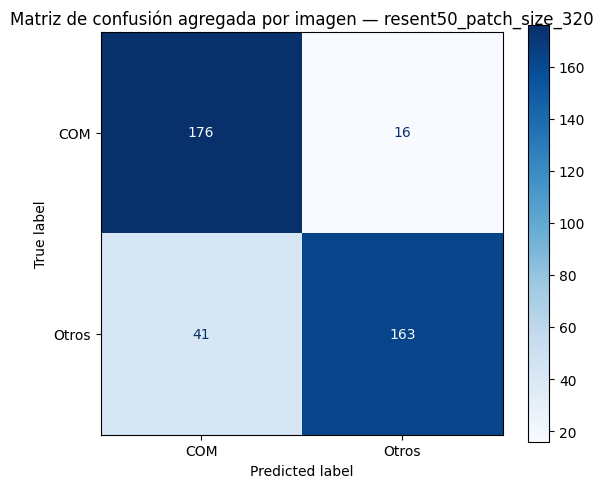

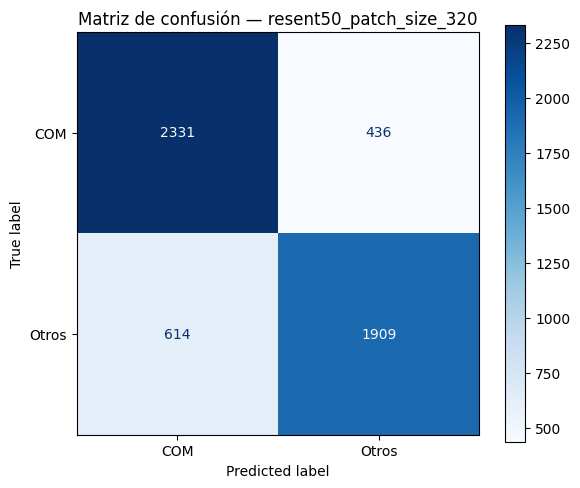


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8028 ± 0.0299
  auc_weighted: 0.8930 ± 0.0163
  f1_weighted: 0.8021 ± 0.0316
  precision_weighted: 0.8121 ± 0.0236
  recall_weighted: 0.8028 ± 0.0299


In [6]:


task= TASKS["binario"]
evaluations= []


for patch_size in PATCH_CONFIG:
        file_name= f"experiments/patches_{patch_size}_metadata.csv"
        patch_df=pd.read_csv(file_name) 
        patches_task = assign_task_labels(patch_df, task)
        exp_name = f"resent50_patch_size_{patch_size}"
        config = {
            "name": exp_name,
            "output_dir": str(f"experiments/patch_size/resnet50/{patch_size}"),
            "batch_size": 16,
            "class_names": task["class_names"],
        }
        resnet50_model = resnet50(patches_task, Case.PATCH)
        result = resnet50_model.run_model(config, show_fold_metrics= True)

        #evaluar el modelo
        evaluations.append(result)
    

In [7]:

results_df= pd.DataFrame(evaluations_to_results(evaluations))
    


resent50_patch_size_224
resent50_patch_size_256
resent50_patch_size_288
resent50_patch_size_320


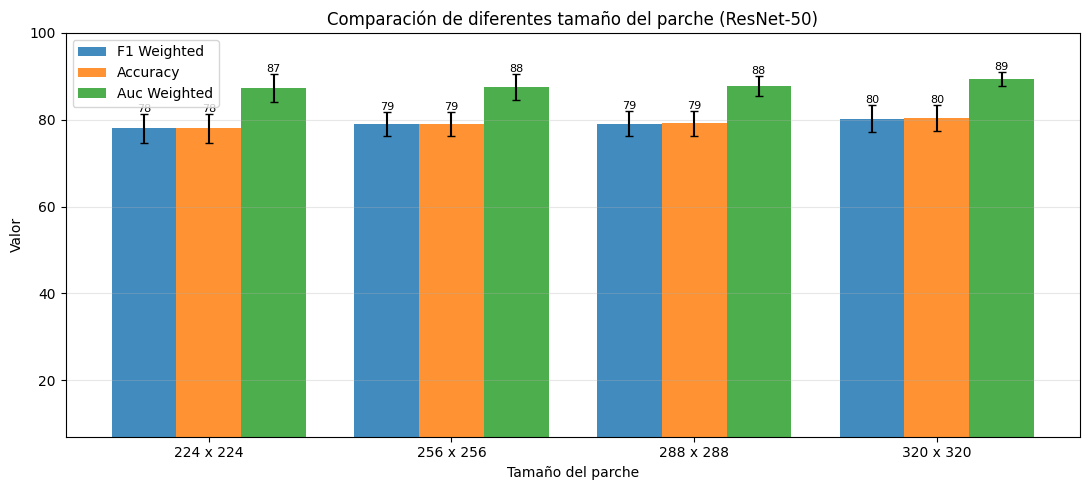

In [10]:

fig_image = plot_lbp_multi_metric(df= results_df, labels = ["224 x 224", "256 x 256", "288 x 288", "320 x 320"], xlabel="Tamaño del parche", ylabel= "Valor", title= "Comparación de diferentes tamaño del parche (ResNet-50)" )
fig_image.show()
fig_image.savefig("experiments/plots/comparación tamaños de parches resnet50", dpi= 100)

In [13]:
#resumen
patches_per_class = patches_df.groupby("folder").agg(
    num_images_per_folder=("stone_id", "nunique"),
    num_patches_per_folder=("patch_id", "size"),
).reset_index()
patches_per_class["avg_patches_per_image"] = (
    patches_per_class["num_patches_per_folder"] / patches_per_class["num_images_per_folder"]
).round(2)
patches_per_class

,folder,num_images_per_folder,num_patches_per_folder,avg_patches_per_image
0,1aI,51,1375,26.96
1,2a,79,1392,17.62
2,3aII,21,298,14.19
3,3bII,57,717,12.58
4,4II-4I,49,655,13.37
5,6,28,485,17.32
6,8aI - 8aII,26,368,14.15


In [14]:

# Conteos por vista
images_per_view = (
    patches_df.groupby(["folder", "view"])["stone_id"]
    .nunique()
    .unstack(fill_value=0)
    .add_prefix("num_images_")
)
patches_per_view = (
    patches_df.groupby(["folder", "view"])["patch_id"]
    .size()
    .unstack(fill_value=0)
    .add_prefix("num_patches_")
)

# Merge todo
patches_per_class = (
    patches_per_class
    .merge(images_per_view.reset_index(), on="folder", how="left")
    .merge(patches_per_view.reset_index(), on="folder", how="left")
    .fillna(0)
)
patches_per_class

,folder,num_images_per_folder,num_patches_per_folder,avg_patches_per_image,num_images_section,num_images_surface,num_patches_section,num_patches_surface
0,1aI,51,1375,26.96,19,46,451,924
1,2a,79,1392,17.62,59,38,880,512
2,3aII,21,298,14.19,2,19,17,281
3,3bII,57,717,12.58,33,26,354,363
4,4II-4I,49,655,13.37,36,15,461,194
5,6,28,485,17.32,22,9,356,129
6,8aI - 8aII,26,368,14.15,18,11,246,122


In [15]:

def patches_per_task_class(patches_df, tasks):
    """
    Para cada tarea, mapea folders a clases y cuenta a tres niveles:
    - num_patches: patches totales por clase
    - num_source_images: archivos físicos de imagen (section, surface, etc.)
    - num_stones: cálculos únicos (stone_id), la unidad estadística real
    
    También desglosa por tipo de vista (section, surface).
    """
    results = {}
    for task_name, task_config in tasks.items():
        folder_to_class = {
            folder: class_name
            for class_name, folders in zip(task_config["class_names"], task_config["classes"])
            for folder in folders
        }
        df_task = patches_df[patches_df["folder"].isin(folder_to_class)].copy()
        df_task["class_name"] = df_task["folder"].map(folder_to_class)
        
        # Resumen general por clase con los tres niveles de conteo
        summary = df_task.groupby("class_name").agg(
            num_patches=("patch_id", "size"),
            num_source_images=("source_image", "nunique"),
            num_stones=("stone_id", "nunique"),
        ).reset_index()
        summary["avg_patches_per_stone"] = (
            summary["num_patches"] / summary["num_stones"]
        ).round(2)
        summary["avg_images_per_stone"] = (
            summary["num_source_images"] / summary["num_stones"]
        ).round(2)
        
        # Conteos por vista (igual que antes, pero con nombres más claros)
        stones_per_view = (
            df_task.groupby(["class_name", "view"])["stone_id"]
            .nunique()
            .unstack(fill_value=0)
            .add_prefix("num_stones_")
        )
        patches_per_view = (
            df_task.groupby(["class_name", "view"])["patch_id"]
            .size()
            .unstack(fill_value=0)
            .add_prefix("num_patches_")
        )
        
        summary = (
            summary
            .merge(stones_per_view.reset_index(), on="class_name", how="left")
            .merge(patches_per_view.reset_index(), on="class_name", how="left")
            .fillna(0)
        )
        
        # Reordenar según class_names
        summary["class_name"] = pd.Categorical(
            summary["class_name"],
            categories=task_config["class_names"],
            ordered=True,
        )
        summary = summary.sort_values("class_name").reset_index(drop=True)
        
        # Convertir conteos a int
        int_cols = [c for c in summary.columns if c.startswith(("num_patches", "num_stones", "num_source_images"))]
        summary[int_cols] = summary[int_cols].astype(int)
        
        results[task_name] = summary
    
    return results

In [16]:

summaries = patches_per_task_class(patches_df, TASKS)

for task_name, summary in summaries.items():
    print(f"\n{task_name} ")
    print(summary.to_string(index=False))


binario 
class_name  num_patches  num_source_images  num_stones  avg_patches_per_stone  avg_images_per_stone  num_stones_section  num_stones_surface  num_patches_section  num_patches_surface
       COM         2767                192         130                  21.28                  1.48                  78                  84                 1331                 1436
     Otros         2523                204         181                  13.94                  1.13                 111                  80                 1434                 1089

multiclase 
class_name  num_patches  num_source_images  num_stones  avg_patches_per_stone  avg_images_per_stone  num_stones_section  num_stones_surface  num_patches_section  num_patches_surface
       COM         2767                192         130                  21.28                  1.48                  78                  84                 1331                 1436
       COD          298                 24          21             

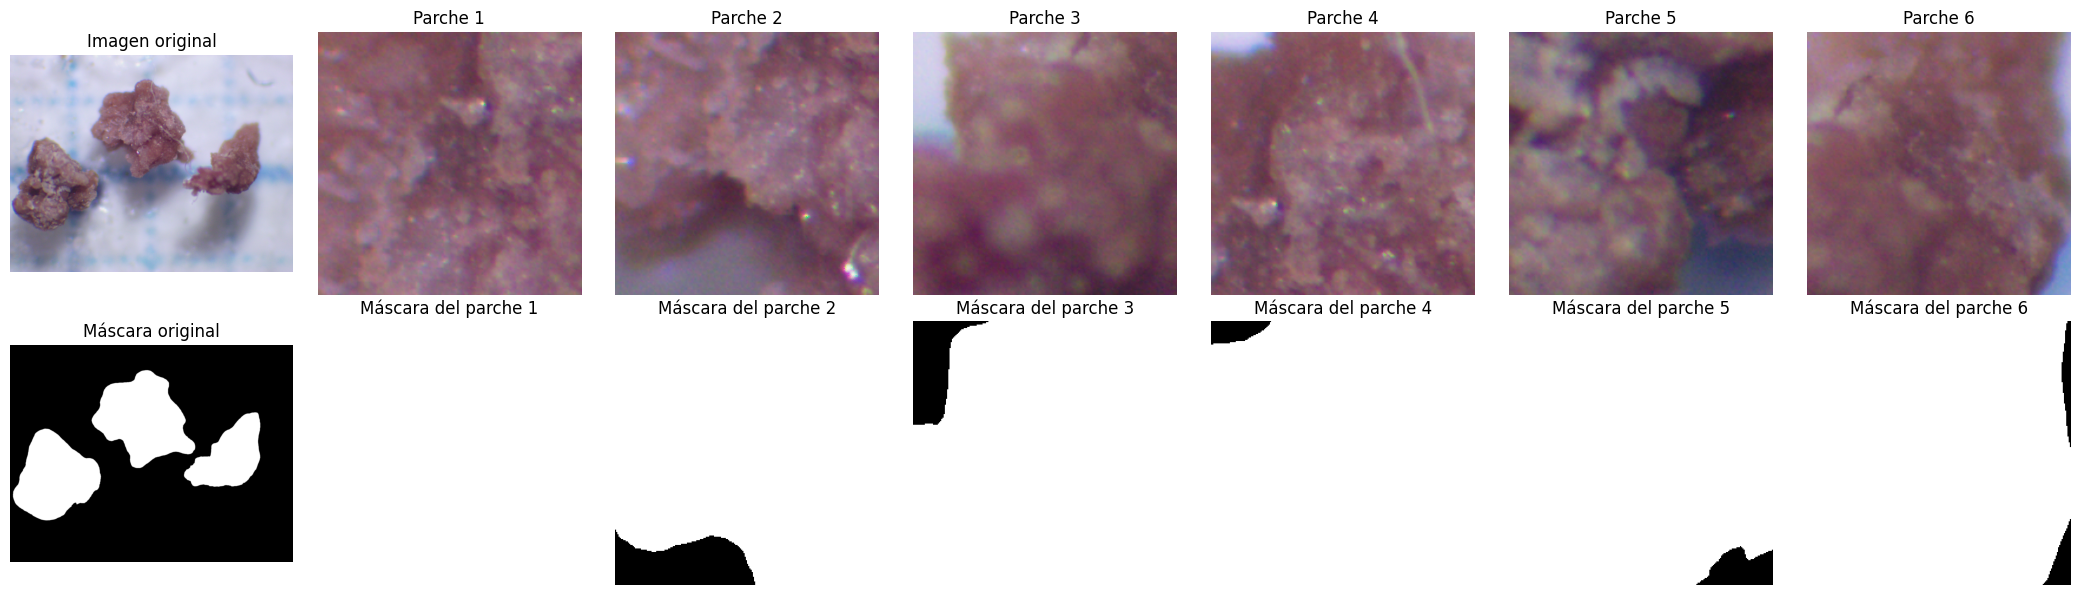

In [17]:
#ejemplo de patches extraídos

# Imagen original y su máscara
image_path = "DATASET/SECTION_SURFACE_DATASET/3aII/section/3aII_2536SE.png"
mask_path  = "DATASET/SECTION_SURFACE_DATASET/3aII/section/MASKS/3aII_2536SE_mask.png"
stone_id   = "3aII_2536SE"

full_image = load_image(image_path)
full_mask  = load_mask(mask_path)

# Metadatos de los parches y filtrado por stone_id
df = pd.read_csv("experiments/patches_224_metadata.csv")
df = df[df["stone_id"] == stone_id]

# Carga de parches y máscaras correspondientes
images, masks = [], []
for _, row in df.iterrows():
    images.append(load_image(row[Case.PATCH.image_col]))
    masks.append(load_mask(row[Case.PATCH.mask_col]))

# Visualización: imagen completa en la primera columna, parches en las siguientes
n_cols = len(images) + 1
n= 6
fig, axes = plt.subplots(2, n+1, figsize=(3 * (n+1), 6))

# Columna 0: imagen original (arriba) y su máscara (abajo)
axes[0, 0].imshow(full_image)
axes[0, 0].set_title("Imagen original")
axes[0, 0].axis("off")

axes[1, 0].imshow(full_mask, cmap="gray")
axes[1, 0].set_title("Máscara original")
axes[1, 0].axis("off")


# Columnas siguientes: cada parche (arriba) y su máscara (abajo)
for i, (img, msk) in enumerate(zip(images[5:n+5], masks[5:n+5]), start=1):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Parche {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(msk, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Máscara del parche {i}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

fig.savefig("experiments/plots/imagen y patches.png", dpi =100)
